# JAMES Thibault & OTMANE Amine - Projet Deep Learning

Dans cette partie nous allons utiliser le jeu de données cifar10 et effectuer du transfert learning par le fine tuning comme dans le cours avec VGG16 qui a bonne réputation.

# Découverte du dataset et ajustement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras 
from tensorflow.keras.applications import VGG16
from tensorflow.keras import backend as K
import tensorflow as tf
from keras import layers
from keras import models
from tensorflow.keras.optimizers.legacy import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
print(X_train.shape, ": X_train")
print(y_train.shape, ": y_train")
print(X_test.shape, ": X_test")
print(y_test.shape, ": y_test")

(50000, 32, 32, 3) : X_train
(50000, 1) : y_train
(10000, 32, 32, 3) : X_test
(10000, 1) : y_test


Notre jeu de données initial est composé de 60000 images de couleurs de 32x32 pixels et on a divisé ce dataset en un train est un test.
Les images dans les ensembles d'entraînement et de test sont originellement stockées sous forme de matrices tridimensionnelles, où les deux premières dimensions représentent la hauteur et la largeur de l'image, et la troisième dimension correspond aux canaux de couleur (Rouge, Vert, Bleu - RVB).

Alors on utilise la fonction reshape pour modifier la forme des matrices d'images en ajoutant une dimension à la fin pour spécifier les trois canaux de couleur.

In [4]:
X_train = X_train.reshape(len(X_train), X_train.shape[1], X_train.shape[2], 3)
X_test = X_test.reshape(len(X_test), X_test.shape[1], X_test.shape[2], 3)

print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


Ensuite, on normalise les données, effectuée ici en divisant chaque pixel par la valeur maximale présente dans l'ensemble de données. L'objectif est d'assurer une échelle uniforme à toutes les valeurs de pixels. 

Cette pratique contribue à la stabilité numérique et favorise une convergence plus rapide des modèles d'apprentissage automatique. En réduisant le risque de saturation des fonctions d'activation.

In [5]:
X_train = X_train / X_train.max()
X_test = X_test / X_test.max()

print("After normalization \n")
print("X_train :  min",X_train.min(), "| max ", X_train.max())
print("X_test :  min",X_test.min(), "| max ", X_test.max())

After normalization 

X_train :  min 0.0 | max  1.0
X_test :  min 0.0 | max  1.0


D'après la documentation on récupère les labels des images et on en affiche 4 pour l'exemple.

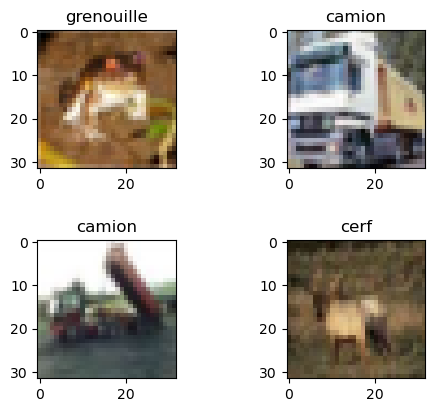

In [6]:
label = ["avion", "voiture", "oiseau", "chat", "cerf", "chien", "grenouille", "cheval", "bateau", "camion"]
rows = 2
columns = 2
_, ax = plt.subplots(rows,columns, figsize=(5,5))
for i, ax in enumerate(ax.flatten()):
    ax.imshow(X_train[i])
    ax.set_title(label[y_train[i][0]])
    plt.subplots_adjust(wspace=0.8)

# Création du réseau de neuronnes

Désormais, on récupère le modèle de base VGG16 qui est entrainé du dataset imagenet,puis il faut ajouter un morceau de réseau de neurones permettant de traiter la classification d'image parmis 10 classes. Nous rendons les 4 derniers couches de convolution du modèle entrainable et les couches plus profondes seront gelées avec les poids pré-entrainés. Le but est de faire du fine tuning.

In [7]:
base_model = VGG16(weights='imagenet',include_top=False,input_shape=(32,32,3))

for layer in base_model.layers[:-4]:
    layer.trainable = False

On ajoute le modèle VGG16 en tant que base, suivi d'une couche Flatten pour aplatir les caractéristiques extraites en un vecteur unidimensionnel. Ensuite, on ajoute deux couches denses, avec la dernière couche utilisant une activation softmax pour la classification sur 10 classes.

Dans la suite on initie les input du notre modèle afin qu'ils puissent recevoir des données d'images pour être développé avec d'autres couches de traitement.

In [8]:
model = tf.keras.Sequential()

In [9]:
model.add(tf.keras.layers.Input((32,32,3)))

Puis nous ajoutons des couches de convolution avec des filtres de taille 3x3 ce qui permet au modèle de détecter des motifs visuels locaux, la normalisation par lots aide à stabiliser et accélérer l'apprentissage, le max pooling réduit la dimensionnalité spatiale, et le dropout introduit une régularisation en désactivant aléatoirement certains neurones pour éviter le surajustement.

Ensuite, la deuxième partie du modèle consiste en des couches entièrement connectées grâce à Flatten, avec une dernière couche softmax de 10 neurones correspondant aux classes de sortie. Ces couches réalisent la classification finale en utilisant les caractéristiques apprises par les couches précédentes.

In [10]:
model.add(base_model)

model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 conv2d (Conv2D)             (None, 1, 1, 64)          294976    
                                                                 
 batch_normalization (Batch  (None, 1, 1, 64)          256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1, 1, 64)          0         
                                                                 
 conv2d_1 (Conv2D)           (None, 1, 1, 128)         73856     
                                                                 
 batch_normalization_1 (Bat  (None, 1, 1, 128)         512       
 chNormalization)                                       

Comme on peut le voir il y a déjà 15 millions de paramètres à calculer alors même que nous avons enlevé un peu de complexité avec les dropout.

Ici on compile notre modèle avec l'optimiseur Adam, et la fonction de perte sparse categorical crossentropy adaptée à la classification multi-classe.

In [12]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

# Partie entraînement et test

Maintenant, nous allons résumer ici en deux cas (car il y en a eu beaucoup d'autres) ce qui nous semblaient pertinant. Tout d'abord, nous avions faire un fit avec 15 epochs, ici nous allons jusqu'à 6 pour le temps de chargement. Nous prennons également un petit batch_size ce qui nous permet de faire beaucoup de "sous-groupes" dans nos epochs. 

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2)

history = model.fit(X_train, y_train, epochs=6, batch_size=64, validation_data=(X_valid, y_valid))

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/6
625/625 [==============================] - 250s 400ms/step - loss: 1.5723 - accuracy: 0.4906 - val_loss: 1.1719 - val_accuracy: 0.6101
Epoch 2/6
625/625 [==============================] - 250s 400ms/step - loss: 1.0189 - accuracy: 0.6557 - val_loss: 1.0097 - val_accuracy: 0.6553
Epoch 3/6
625/625 [==============================] - 253s 405ms/step - loss: 0.8896 - accuracy: 0.7032 - val_loss: 0.9603 - val_accuracy: 0.6846
Epoch 4/6
625/625 [==============================] - 242s 388ms/step - loss: 0.8102 - accuracy: 0.7283 - val_loss: 0.8824 - val_accuracy: 0.7139
Epoch 5/6
625/625 [==============================] - 249s 399ms/step - loss: 0.7413 - accuracy: 0.7541 - val_loss: 0.8458 - val_accuracy: 0.7230
Epoch 6/6
313/313 [==============================] - 32s 101ms/step - loss: 1.0514 - accuracy: 0.6659
Test Loss: 1.0514
Test Accuracy: 0.6659


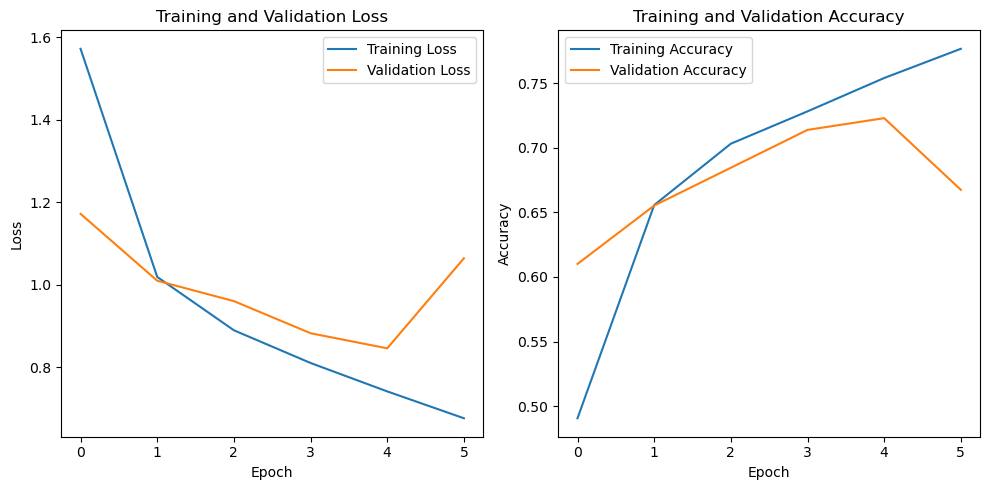

In [14]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Comme nous pouvons très bien le voir sur les graphiques très rapidement nous avons une perte de vitesse. Quand nous avons essayé avec 15 epochs et il y a qu'un sur-apprentissage qui se met en place très clair à partir de 6. Nous ne gagnons que très peu de précisions sur les tests. Il y a quand même une précision de 70% à la fin et un cout assez minime. Dans les deux cas, ici nous avons la courbe de validation qui est moins bonne que la courbe de training ce qui est totalement normal. 

Enfin, le test qui a été effectué sur des données non utilisées dans l'apprentissage montre un taux de réussite de 67% ce qui est plutôt bon sachant que nous avons 10 catégories à identifier et le cout est aussi faible. Nous avons réussi à avoir 70% plusieurs fois avec ce modèle.

Nous passons au second cas que nous voulons présenter. Nous reprenons un réseau de neurones similaire au premier cas,  mais nous augmentons la taille du batch_size pour réduire le nombre de calculs et nous prenons que 5 epochs car nous avons vu dans le premier cas que pour plus il y a du sur apprentissage. Nous avons aussi voulu réduire les parties d'apprentissage sur chaque époch en passant de 20% à 40%.

In [15]:
model2 = models.Sequential()
model2.add(base_model)


model2.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model2.add(tf.keras.layers.BatchNormalization())
model2.add(tf.keras.layers.Dropout(0.25))

model2.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model2.add(tf.keras.layers.BatchNormalization())
model2.add(tf.keras.layers.Dropout(0.25))

model2.add(tf.keras.layers.Flatten())
model2.add(tf.keras.layers.Dense(256, activation='relu'))
model2.add(tf.keras.layers.BatchNormalization())
model2.add(tf.keras.layers.Dropout(0.5))

model2.add(tf.keras.layers.Dense(10, activation='softmax'))


X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.4)


model2.compile(optimizer=Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
history2 = model2.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_valid, y_valid))

test_loss, test_acc = model2.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/5
94/94 [==============================] - 173s 2s/step - loss: 0.7744 - accuracy: 0.7626 - val_loss: 0.8290 - val_accuracy: 0.7812
Epoch 2/5
94/94 [==============================] - 169s 2s/step - loss: 0.5328 - accuracy: 0.8338 - val_loss: 0.5851 - val_accuracy: 0.8204
Epoch 3/5
94/94 [==============================] - 177s 2s/step - loss: 0.4369 - accuracy: 0.8625 - val_loss: 0.5923 - val_accuracy: 0.8111
Epoch 4/5
94/94 [==============================] - 189s 2s/step - loss: 0.3771 - accuracy: 0.8826 - val_loss: 0.5278 - val_accuracy: 0.8349
Epoch 5/5
313/313 [==============================] - 37s 117ms/step - loss: 1.0819 - accuracy: 0.7350
Test Loss: 1.0819
Test Accuracy: 0.7350


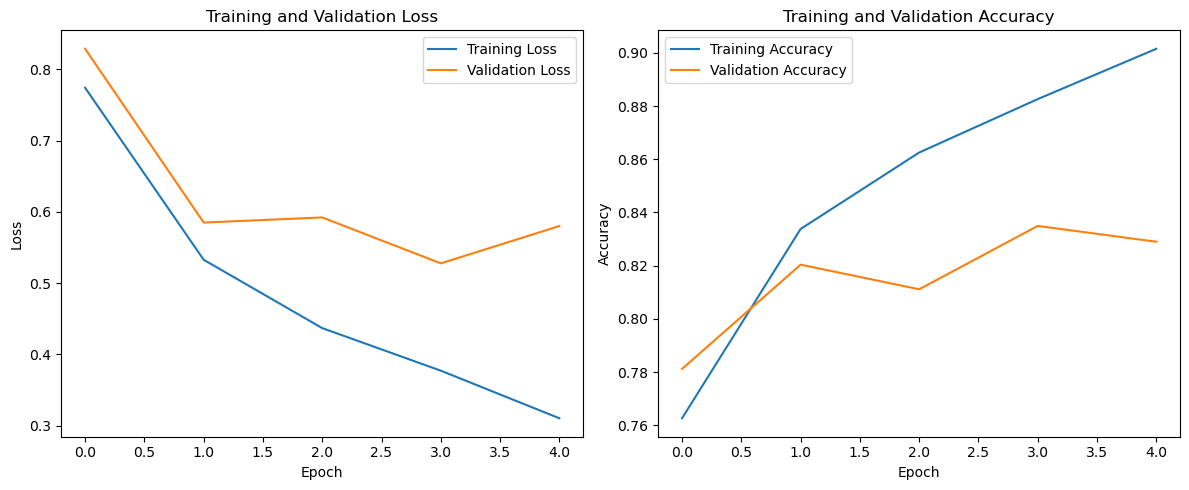

In [17]:
train_loss = history2.history['loss']
val_loss = history2.history['val_loss']
train_acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Conclusion : On pensait avoir besoin de beaucoup d'epochs et beaucoup de minibatch mais il semblerait que le jeu de donnée soit bien traitée avec des paramètres faibles lorsque le modèle a bien été adapté en partant du modèle pré construit VGG16 qui est l'un des meilleurs modèles référéncés dans la liste sur Keras. Nous obtenons une précision de 74% sur les données qui n'ont pas été utilisées dans l'entraînement ce qui est très bon.

Nous allons pour finir présenter les résultats du modèle sur 4 images :

1/1 [==============================] - 0s 221ms/step


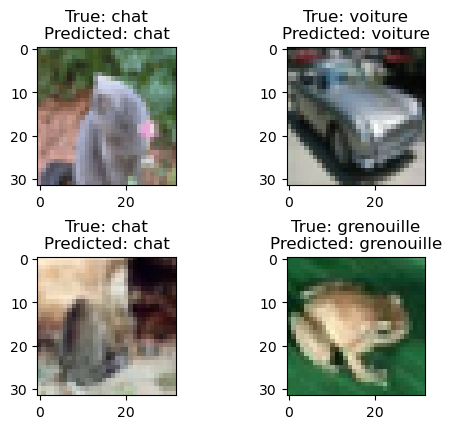

In [18]:
predictions = model.predict(X_train[:4])

predicted_labels = np.argmax(predictions, axis=1)

label = ["avion", "voiture", "oiseau", "chat", "cerf", "chien", "grenouille", "cheval", "bateau", "camion"]
rows = 2
columns = 2

_, ax = plt.subplots(rows, columns, figsize=(5, 5))

for i, ax in enumerate(ax.flatten()):
    ax.imshow(X_train[i])
    true_label = label[y_train[i][0]]
    predicted_label = label[predicted_labels[i]]
    ax.set_title(f'True: {true_label}\nPredicted: {predicted_label}')
    plt.subplots_adjust(wspace=0.8)

plt.show()

Ensuite, nous voyons les modèles CNN et LSTM sur données temporelles.

In [72]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, LSTM
from __future__ import print_function
import math
from keras.layers import Dense, Activation ,Dropout , Flatten , Conv1D ,MaxPooling1D
from keras import losses
from keras import optimizers
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [49]:
data = pd.read_csv('MSFT.csv')

# Introduction au jeu de données
Le jeu de données MSFT.csv contient les cours d'actions de Microsoft de 1986 à 2024. Les données sont organisées en plusieurs colonnes :

Date: La date à laquelle les données ont été enregistrées.
Open: Le prix d'ouverture de l'action Microsoft pour la journée donnée.
High: Le prix le plus élevé atteint par l'action Microsoft au cours de la journée.
Low: Le prix le plus bas atteint par l'action Microsoft au cours de la journée.
Close: Le prix de clôture de l'action Microsoft pour la journée donnée.
Adj Close: Le prix de clôture ajusté en fonction des événements de dividende, de scission d'actions, etc. Ceci est important pour refléter les changements structurels dans l'entreprise.
Volume: Le volume de transactions, c'est-à-dire le nombre total d'actions échangées pendant la journée.
Il est important de toujours utiliser des données récentes et pertinentes pour la construction de modèles prédictifs, en particulier dans des domaines aussi dynamiques et changeants que les marchés financiers. On prendra les données à partie de l'année 2019

In [50]:
data['Date'] = pd.to_datetime(data['Date'])

# Filtrer les données à partir de 2018
data = data[data['Date'].dt.year >= 2018]

In [51]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
8018,2018-01-02,86.129997,86.309998,85.500000,85.949997,80.228996,22483800
8019,2018-01-03,86.059998,86.510002,85.970001,86.349998,80.602356,26061400
8020,2018-01-04,86.589996,87.660004,86.570000,87.110001,81.311798,21912000
8021,2018-01-05,87.660004,88.410004,87.430000,88.190002,82.319939,23407100
8022,2018-01-08,88.199997,88.580002,87.599998,88.279999,82.403908,22113000


L'objectif principal de l'utilisation de ce jeu de données est de développer des modèles prédictifs capables d'estimer le prix de clôture de l'action Microsoft pour une journée donnée.

Pour atteindre l'objectif de prédiction du prix de clôture, nous envisageons d'explorer l'utilisation de deux architectures de réseaux de neurones : les Convolutional Neural Networks (CNN) et les Long Short-Term Memory networks (LSTM).

Les CNN sont souvent utilisés dans le traitement d'images, mais ils peuvent également être appliqués à des séries temporelles unidimensionnelles comme celles des prix d'actions. Ils sont efficaces pour extraire des caractéristiques pertinentes des séquences de données.

Les LSTM, d'autre part, sont des réseaux de neurones récurrents qui sont bien adaptés pour traiter des séquences de données temporelles, car ils sont capables de retenir des informations à long terme.

En combinant ces deux architectures, nous chercherons à exploiter les caractéristiques temporelles et structurelles des données financières pour construire un modèle robuste de prédiction du prix de clôture de l'action Microsoft.

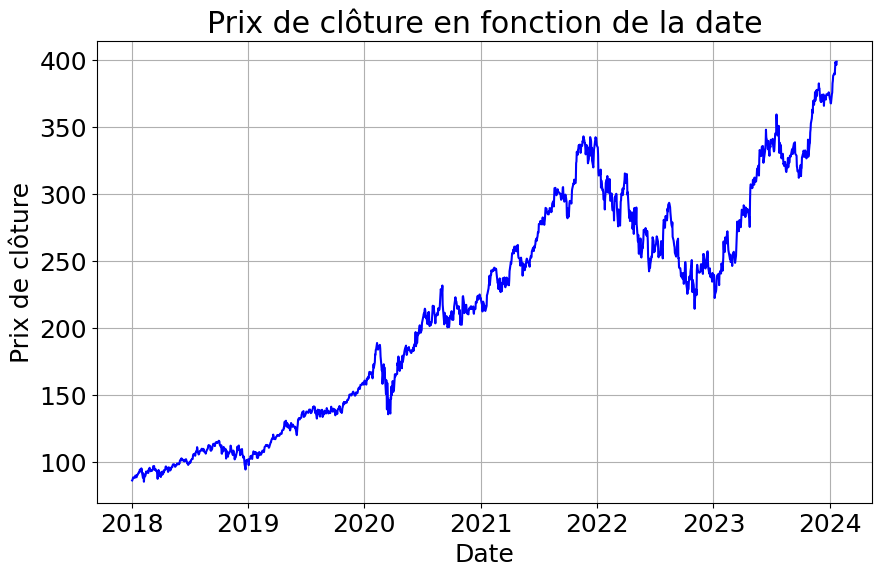

In [52]:
data['Date'] = pd.to_datetime(data['Date'])

plt.figure(figsize=(10, 6))
plt.plot(data['Date'], data['Close'], color='blue', linestyle='-')
plt.title('Prix de clôture en fonction de la date')
plt.xlabel('Date')
plt.ylabel('Prix de clôture')
plt.grid(True)
plt.show()

In [53]:
data.drop(data.columns[[5,6]], axis=1, inplace=True)
df = data.set_index('Date')

df.head()

,Open,High,Low,Close
Date,,,,
2018-01-02,86.129997,86.309998,85.500000,85.949997
2018-01-03,86.059998,86.510002,85.970001,86.349998
2018-01-04,86.589996,87.660004,86.570000,87.110001
2018-01-05,87.660004,88.410004,87.430000,88.190002
2018-01-08,88.199997,88.580002,87.599998,88.279999


### Normalisation

On doit normaliser les données ici aussi.

In [54]:
scaler = MinMaxScaler(feature_range=(0,1))
data = scaler.fit_transform(df)

In [55]:
result = []
sequence_length = 6
for index in range(len(data) - sequence_length):
    result.append(data[index: index + sequence_length])
    
result = np.array(result)

row = round(0.8 * result.shape[0])

#creating training data
train = result[:int(row), :]

x_train = train[:, :-1]
y_train = train[:, -1][:,-1]
x_test = result[int(row):, :-1]
y_test = result[int(row):, -1][:,-1]

amount_of_features = len(df.columns)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features)) 

print("X_train", x_train.shape)
print("y_train", y_train.shape)
print("X_test", x_test.shape)
print("y_test", y_test.shape)

X_train (1214, 5, 4)
y_train (1214,)
X_test (304, 5, 4)
y_test (304,)


Ce code prépare les données pour un modèle d'apprentissage en prenant 80% dans le train set.

In [56]:
def build_model(input):
    model = Sequential()
    model.add(Dense(128,input_shape=(input[1],input[0])))
    model.add(Conv1D(filters = 112, kernel_size= 1,padding='valid', activation='relu', kernel_initializer="uniform"))
    model.add(MaxPooling1D(pool_size=2, padding='valid'))
    model.add(Conv1D(filters = 64,kernel_size = 1,padding='valid', activation='relu', kernel_initializer="uniform"))
    model.add(MaxPooling1D(pool_size=1, padding='valid'))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(100, activation="relu", kernel_initializer="uniform"))
    #model.add(Dropout(0.2))
    model.add(Dense(1, activation="relu", kernel_initializer="uniform"))
    model.compile(loss='mse',optimizer='adam',metrics=['mae'])
    return model

1. `Dense(128, input_shape=(input[1], input[0]))` : Cette couche dense contient 128 neurones et définit la forme de l'entrée du modèle.
2. `Conv1D(filters=112, kernel_size=1, padding='valid', activation='relu', kernel_initializer="uniform")` : Une couche de convolution 1D avec 112 filtres, une taille de noyau de 1 et une activation ReLU.
3. `MaxPooling1D(pool_size=2, padding='valid')` : Une couche de pooling pour réduire la dimensionnalité des caractéristiques extraites par la couche de convolution.
4. `Conv1D(filters=64, kernel_size=1, padding='valid', activation='relu', kernel_initializer="uniform")` : Une autre couche de convolution 1D avec 64 filtres et une activation ReLU.
5. `MaxPooling1D(pool_size=1, padding='valid')` : Une autre couche de pooling.
6. `Dropout(0.2)` : Une couche de dropout pour régulariser le modèle et réduire le surapprentissage.
7. `Flatten()` : Une couche pour aplatir les données avant de les passer à une couche dense.
8. `Dense(100, activation="relu", kernel_initializer="uniform")` : Une couche dense avec 100 neurones et une activation ReLU.
9. `Dense(1, activation="relu", kernel_initializer="uniform")` : Une couche de sortie avec un seul neurone et une activation ReLU, destinée à prédire une valeur continue.
10. `model.compile(loss='mse', optimizer='adam', metrics=['mae'])` : Compilation du modèle avec une fonction de perte MSE (Mean Squared Error), un optimiseur Adam et les métriques MAE (Mean Absolute Error).

La fonction renvoie le modèle ainsi créé et compilé pour être utilisé dans l'apprentissage et l'évaluation des données.

In [57]:
model = build_model([4,5,1])
#Summary of the Model
print(model.summary())

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 5, 128)            640       
                                                                 
 conv1d_2 (Conv1D)           (None, 5, 112)            14448     
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 2, 112)            0         
 g1D)                                                            
                                                                 
 conv1d_3 (Conv1D)           (None, 2, 64)             7232      
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 2, 64)             0         
 g1D)                                                            
                                                                 
 dropout_9 (Dropout)         (None, 2, 64)            

In [58]:
from timeit import default_timer as timer
start = timer()
history = model.fit(x_train,
                    y_train,
                    batch_size=128,
                    epochs=20,
                    validation_split=0.2,
                    verbose=2)
end = timer()
print(end - start)

Epoch 1/20
8/8 - 0s - loss: 0.1084 - mae: 0.2565 - val_loss: 0.2937 - val_mae: 0.5346 - 265ms/epoch - 33ms/step
Epoch 2/20
8/8 - 0s - loss: 0.0458 - mae: 0.1531 - val_loss: 0.0015 - val_mae: 0.0315 - 29ms/epoch - 4ms/step
Epoch 3/20
8/8 - 0s - loss: 0.0151 - mae: 0.1143 - val_loss: 0.0123 - val_mae: 0.1026 - 27ms/epoch - 3ms/step
Epoch 4/20
8/8 - 0s - loss: 0.0082 - mae: 0.0722 - val_loss: 0.0210 - val_mae: 0.1383 - 31ms/epoch - 4ms/step
Epoch 5/20
8/8 - 0s - loss: 0.0043 - mae: 0.0559 - val_loss: 0.0027 - val_mae: 0.0436 - 28ms/epoch - 4ms/step
Epoch 6/20
8/8 - 0s - loss: 0.0027 - mae: 0.0447 - val_loss: 0.0057 - val_mae: 0.0675 - 29ms/epoch - 4ms/step
Epoch 7/20
8/8 - 0s - loss: 0.0015 - mae: 0.0303 - val_loss: 0.0020 - val_mae: 0.0360 - 29ms/epoch - 4ms/step
Epoch 8/20
8/8 - 0s - loss: 8.4662e-04 - mae: 0.0210 - val_loss: 9.4099e-04 - val_mae: 0.0259 - 28ms/epoch - 4ms/step
Epoch 9/20
8/8 - 0s - loss: 8.8933e-04 - mae: 0.0203 - val_loss: 0.0012 - val_mae: 0.0286 - 29ms/epoch - 4ms/s

In [59]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

Pour les valeurs de séries temporelles, la métrique habituellement utilisée est l'erreur moyenne absolue (MAE - Mean Absolute Error) plutôt que l'accuracy. Cela est dû à la nature des prédictions de séries temporelles, où l'objectif est de minimiser l'écart entre les valeurs prédites et les valeurs réelles.

L'accuracy, qui est généralement utilisée dans les tâches de classification, mesure la proportion de prédictions correctes parmi toutes les prédictions. Dans le cas des séries temporelles, où nous prévoyons des valeurs continues plutôt que des catégories discrètes, l'accuracy n'est pas une métrique appropriée.

Pour les valeurs de séries temporelles, la métrique habituellement utilisée est l'erreur moyenne absolue (MAE - Mean Absolute Error) plutôt que l'accuracy. Cela est dû à la nature des prédictions de séries temporelles, où l'objectif est de minimiser l'écart entre les valeurs prédites et les valeurs réelles.

L'accuracy, qui est généralement utilisée dans les tâches de classification, mesure la proportion de prédictions correctes parmi toutes les prédictions. Dans le cas des séries temporelles, où nous prévoyons des valeurs continues plutôt que des catégories discrètes, l'accuracy n'est pas une métrique appropriée.

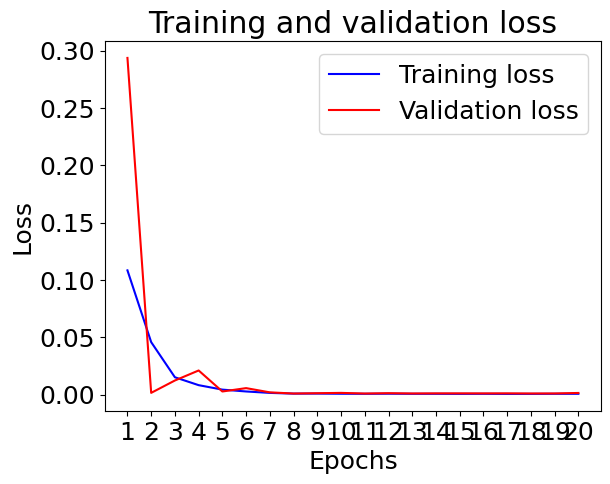

In [82]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
loss_values50 = loss_values[0:150]
val_loss_values50 = val_loss_values[0:150]
epochs = range(1, len(loss_values50) + 1)
plt.plot(epochs, loss_values50, 'b',color = 'blue', label='Training loss')
plt.plot(epochs, val_loss_values50, 'b',color='red', label='Validation loss')
plt.rc('font', size = 18)
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xticks(epochs)
fig = plt.gcf()
plt.show()

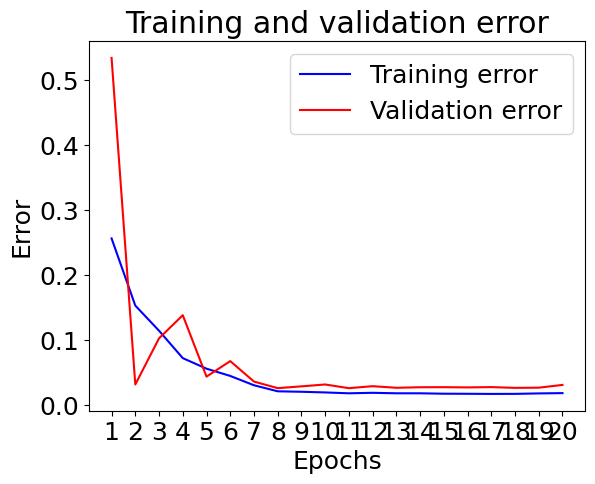

In [83]:
mae = history_dict['mae']
vmae = history_dict['val_mae']
epochs = range(1, len(mae) + 1)
plt.plot(epochs, mae, 'b',color = 'blue', label='Training error')
plt.plot(epochs, vmae, 'b',color='red', label='Validation error')
plt.title('Training and validation error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()
plt.xticks(epochs)
fig = plt.gcf()
plt.show()

Les résultats obtenus montrent que la courbe de perte de validation et de perte d'entraînement converge vers l'époque 7, ce qui indique une stabilisation du modèle. De plus, les performances de prédiction du modèle sont jugées bonnes, ce qui suggère que le modèle CNN est capable de capturer les schémas et les tendances du marché financier.

In [62]:
trainScore = model.evaluate(x_train, y_train, verbose=0)
testScore = model.evaluate(x_test, y_test, verbose=0)

In [63]:
#predicting values for y_test
p1 = model.predict(x_test)

10/10 [==============================] - 0s 554us/step


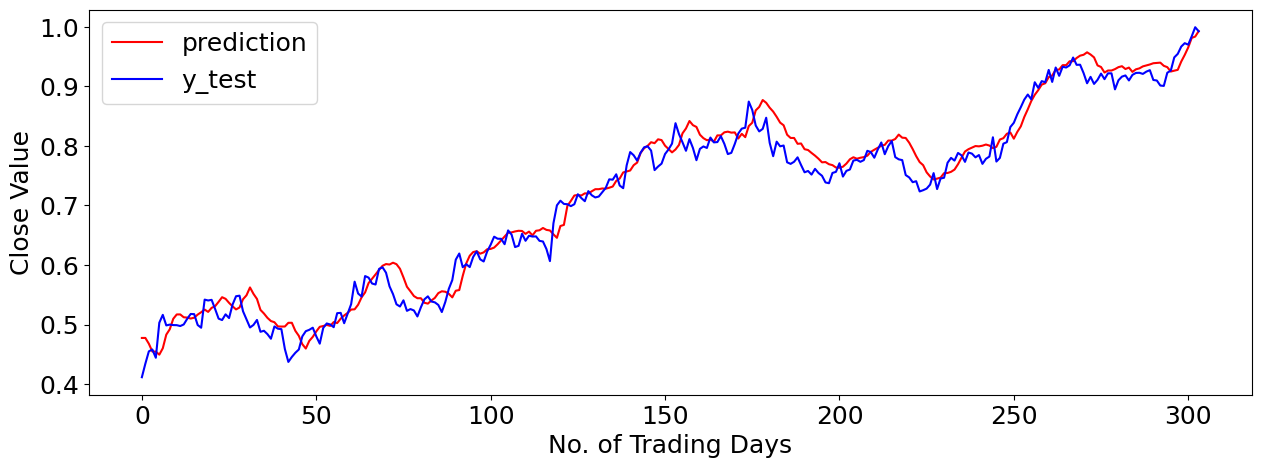

In [64]:
plt.plot(p1,color='red', label='prediction')
plt.plot(y_test,color='blue', label='y_test')
plt.xlabel('No. of Trading Days')
plt.ylabel('Close Value')
plt.legend(loc='upper left')
fig = plt.gcf()
fig.set_size_inches(15, 5)
plt.show()

In [65]:
p1= model.predict(x_train)

38/38 [==============================] - 0s 477us/step


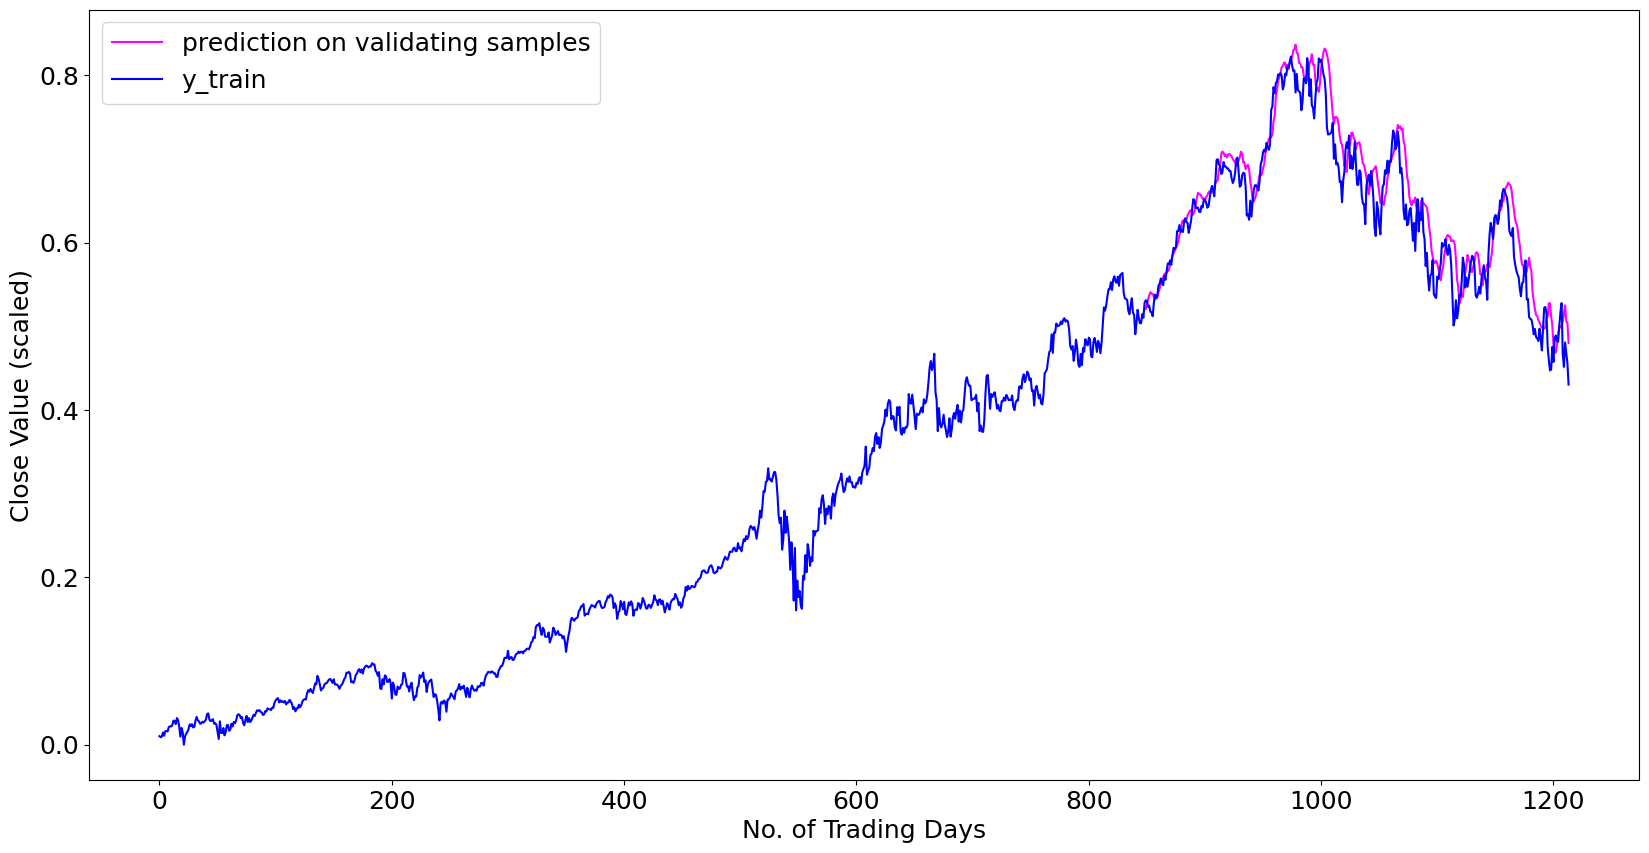

In [66]:
x = np.array(range(848,1214))
plt.plot(x,p1[848:],color = 'magenta',label ='prediction on validating samples')
plt.plot(y_train,color='blue', label='y_train')
plt.xlabel('No. of Trading Days')
plt.ylabel('Close Value (scaled)')
plt.legend(loc='upper left')
fig = plt.gcf()
fig.set_size_inches(20,10)
plt.show()

Le modèle CNN est bien adapté à la tâche de prédiction des performances du marché financier à partir de l'année 2018

# Modèle LSTM

In [67]:
result = []
sequence_length = 6
for index in range(len(data) - sequence_length):
    result.append(data[index: index + sequence_length])
    
result = np.array(result)
row = round(0.8 * result.shape[0])

train = result[:int(row), :]

x_train = train[:, :-1]
y_train = train[:, -1][:,-1]
x_test = result[int(row):, :-1]
y_test = result[int(row):, -1][:,-1]

amount_of_features = len(df.columns)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features)) 

print("X_train", x_train.shape)
print("y_train", y_train.shape)
print("X_test", x_test.shape)
print("y_test", y_test.shape)

X_train (1214, 5, 4)
y_train (1214,)
X_test (304, 5, 4)
y_test (304,)


In [68]:
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(units=1))  

    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

input_shape = (5, 4)  #pas de temporalité && variables
model = build_lstm_model(input_shape)

In [69]:
history = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_data=(x_test, y_test))

Epoch 1/20
19/19 [==============================] - 1s 18ms/step - loss: 0.0592 - mae: 0.1752 - val_loss: 0.0095 - val_mae: 0.0940
Epoch 2/20
19/19 [==============================] - 0s 4ms/step - loss: 0.0103 - mae: 0.0817 - val_loss: 0.0105 - val_mae: 0.0941
Epoch 3/20
19/19 [==============================] - 0s 4ms/step - loss: 0.0045 - mae: 0.0543 - val_loss: 0.0017 - val_mae: 0.0354
Epoch 4/20
19/19 [==============================] - 0s 4ms/step - loss: 0.0035 - mae: 0.0418 - val_loss: 5.8168e-04 - val_mae: 0.0189
Epoch 5/20
19/19 [==============================] - 0s 4ms/step - loss: 0.0036 - mae: 0.0393 - val_loss: 6.0064e-04 - val_mae: 0.0192
Epoch 6/20
19/19 [==============================] - 0s 4ms/step - loss: 0.0034 - mae: 0.0388 - val_loss: 5.8395e-04 - val_mae: 0.0191
Epoch 7/20
19/19 [==============================] - 0s 4ms/step - loss: 0.0033 - mae: 0.0385 - val_loss: 7.1269e-04 - val_mae: 0.0215
Epoch 8/20
19/19 [==============================] - 0s 4ms/step - loss: 0

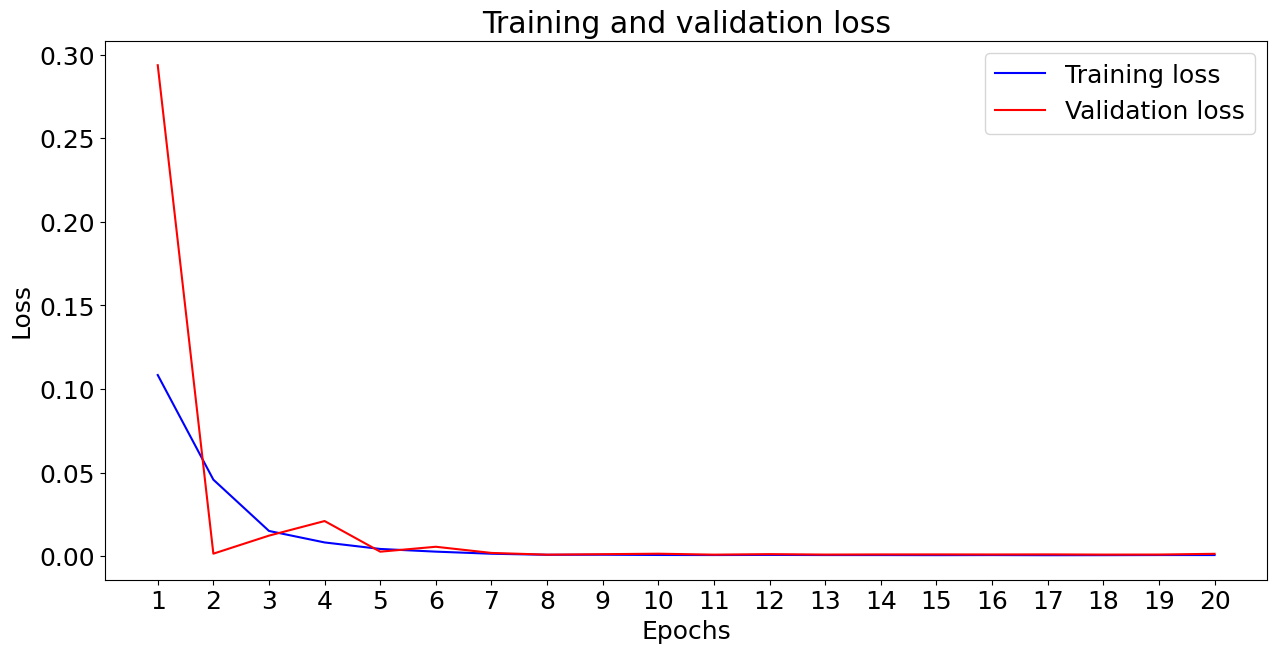

In [75]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
loss_values50 = loss_values[0:150]
val_loss_values50 = val_loss_values[0:150]
epochs = range(1, len(loss_values50) + 1)
plt.plot(epochs, loss_values50, 'b',color = 'blue', label='Training loss')
plt.plot(epochs, val_loss_values50, 'b',color='red', label='Validation loss')
plt.rc('font', size = 18)
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xticks(epochs)
fig = plt.gcf()
fig.set_size_inches(15,7)
plt.show()

10/10 [==============================] - 0s 1ms/step


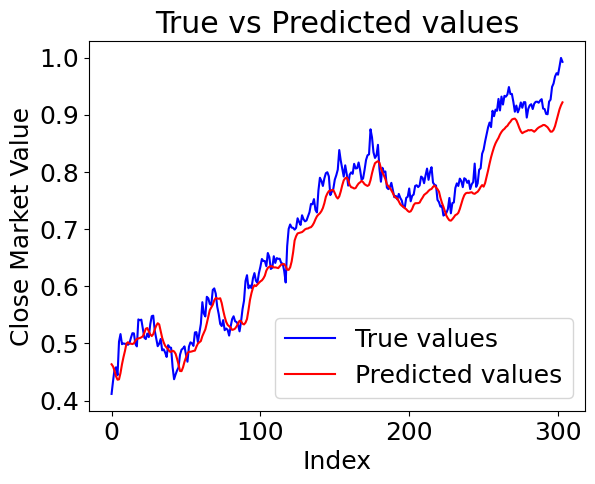

In [71]:
y_pred = model.predict(x_test)
plt.plot(y_test, label='True values', color='blue')
plt.plot(y_pred, label='Predicted values', color='red')
plt.xlabel('Index')
plt.ylabel('Close Market Value')
plt.title('True vs Predicted values')
plt.legend()
plt.show()

Le modèle s'ajuste bien aux données et on remarque qu'à partir de l'époch 4 on obtient un effet plateau.